<a href="https://colab.research.google.com/github/liamarganingrahayu/Website-Event/blob/main/Natural_Style_Transfer_(Gaya_Batik_ke_Kemeja).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Versi TensorFlow: 2.19.0

--- 1. Proses Mounting Google Drive ---
Mounted at /content/drive
Google Drive berhasil di-mount. File siap diakses.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


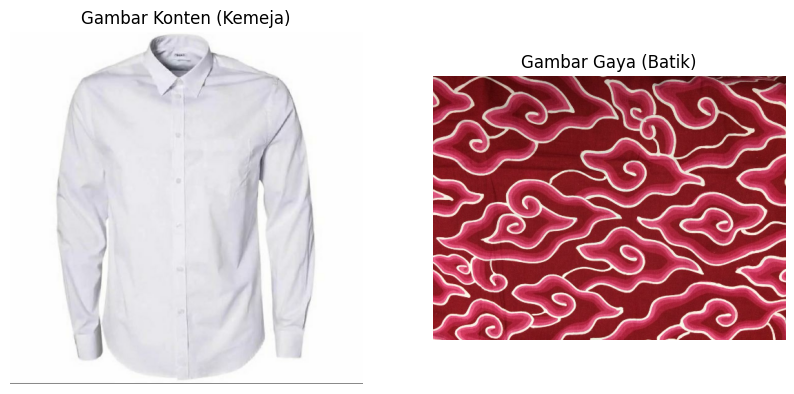


--- 7. Memulai Proses Transfer Gaya Neural ---
Ini adalah langkah yang paling penting. Kami akan menggunakan model VGG19 untuk mengekstrak fitur dan Adam Optimizer untuk meminimalkan loss.
Iterasi 100/1000 | Waktu: 14.20s | Loss Total: 43409888.00
   Loss Konten: 3034328.25, Loss Gaya: 37356456.00, Loss TV: 3019105.25


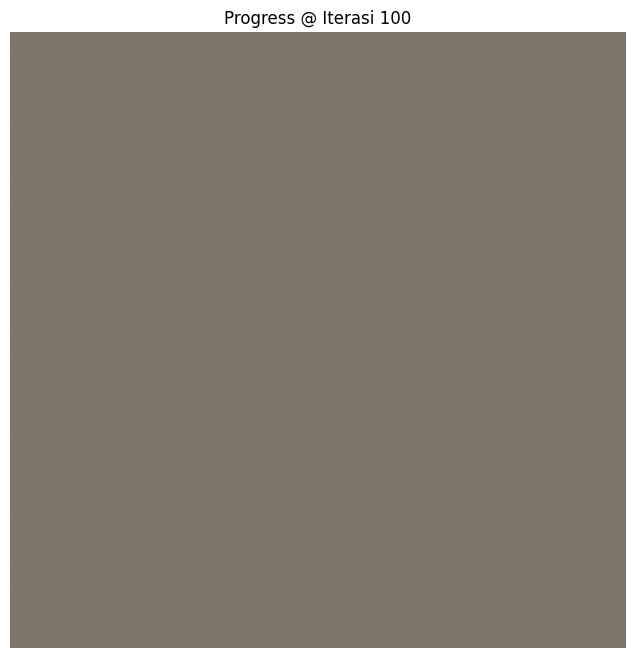

Iterasi 200/1000 | Waktu: 24.31s | Loss Total: 24711516.00
   Loss Konten: 2777911.50, Loss Gaya: 18872526.00, Loss TV: 3061077.25


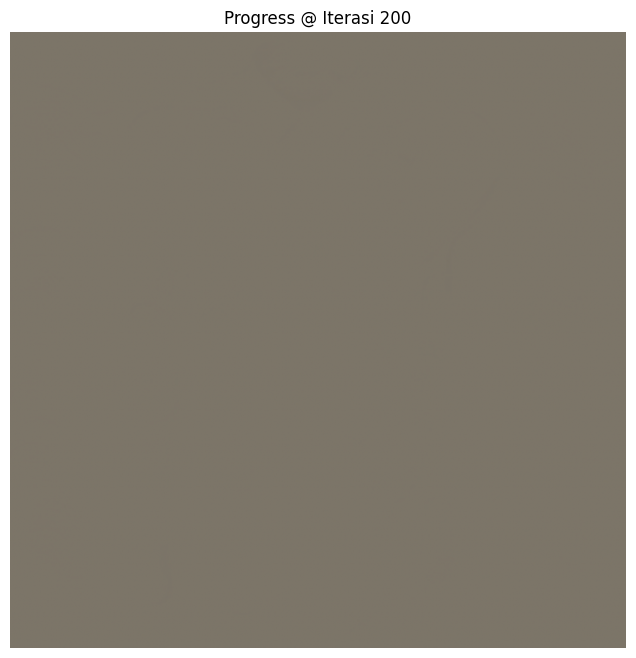

Iterasi 300/1000 | Waktu: 34.35s | Loss Total: 18048264.00
   Loss Konten: 2609731.50, Loss Gaya: 12474274.00, Loss TV: 2964257.25


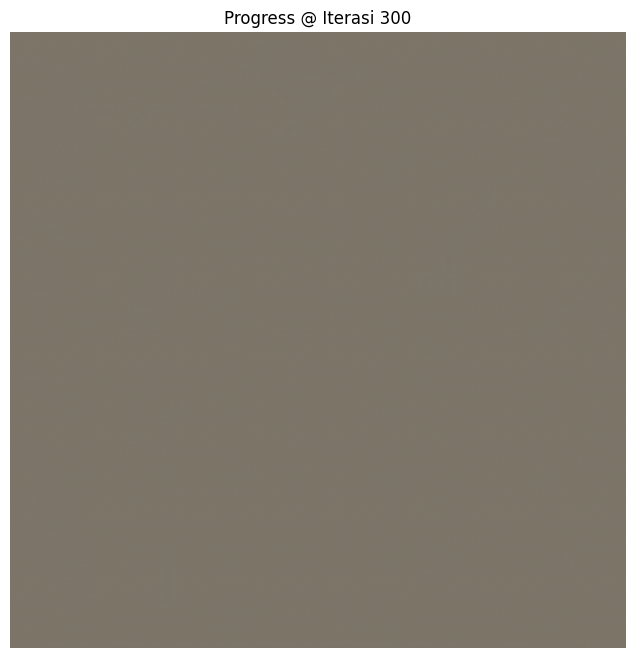

Iterasi 400/1000 | Waktu: 44.58s | Loss Total: 14440130.00
   Loss Konten: 2464780.00, Loss Gaya: 9138397.00, Loss TV: 2836953.25


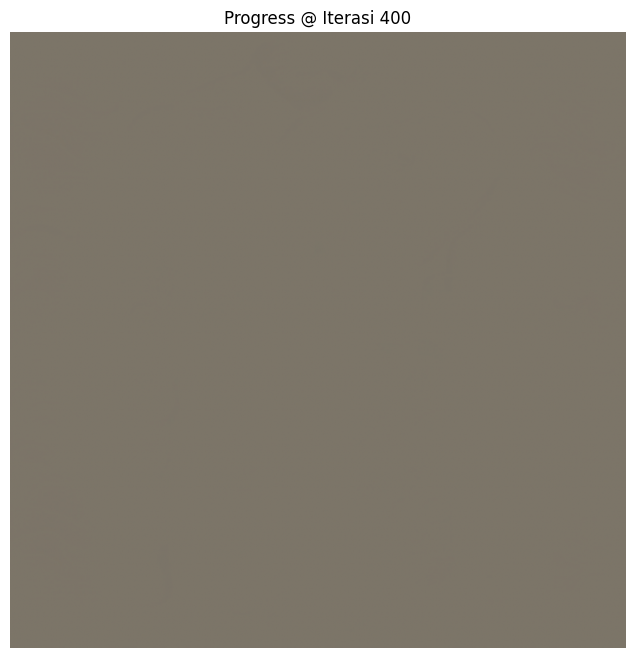

Iterasi 500/1000 | Waktu: 54.41s | Loss Total: 12274785.00
   Loss Konten: 2341910.00, Loss Gaya: 7223648.50, Loss TV: 2709227.00


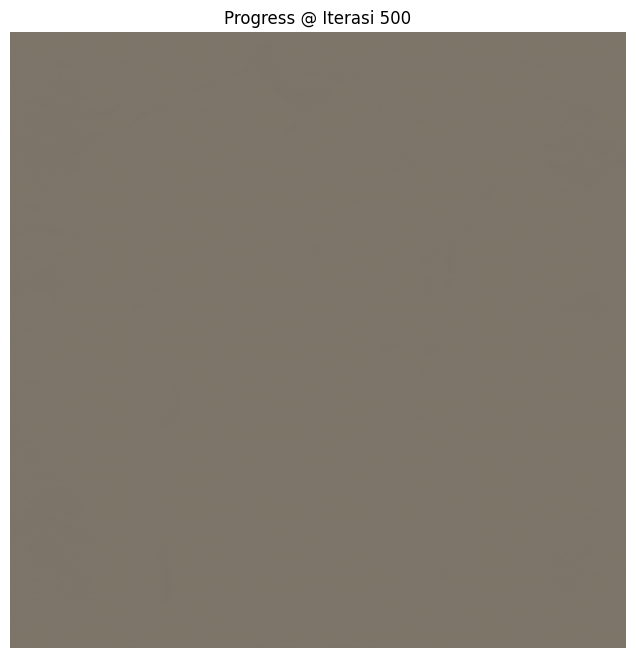

Iterasi 600/1000 | Waktu: 64.01s | Loss Total: 12108230.00
   Loss Konten: 2364108.50, Loss Gaya: 6903943.00, Loss TV: 2840178.00


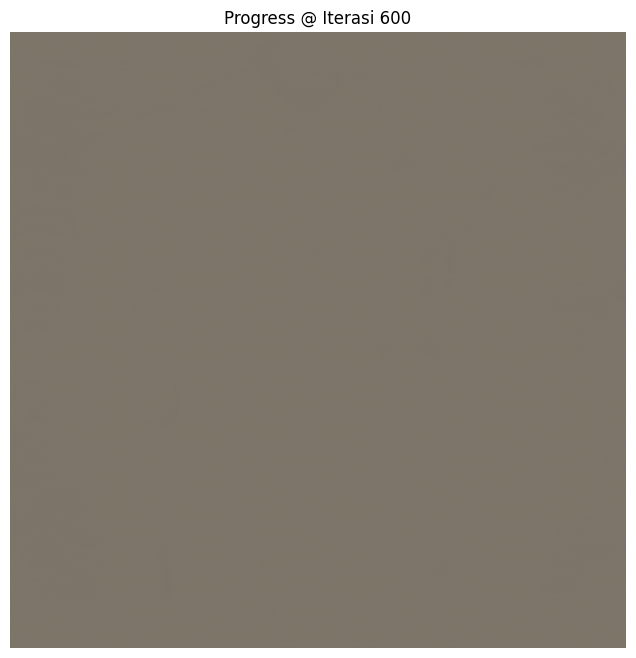

Iterasi 700/1000 | Waktu: 73.74s | Loss Total: 9524072.00
   Loss Konten: 2157273.00, Loss Gaya: 4821634.00, Loss TV: 2545165.50


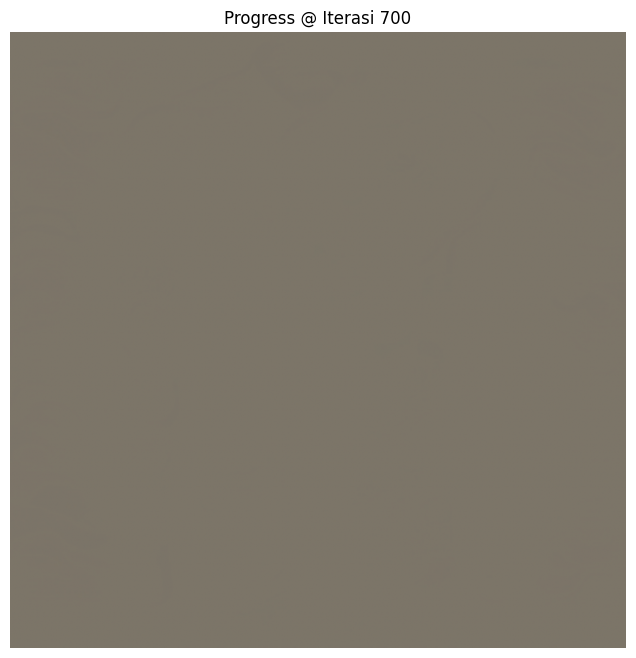

Iterasi 800/1000 | Waktu: 83.21s | Loss Total: 8770760.00
   Loss Konten: 2085031.75, Loss Gaya: 4263012.50, Loss TV: 2422716.50


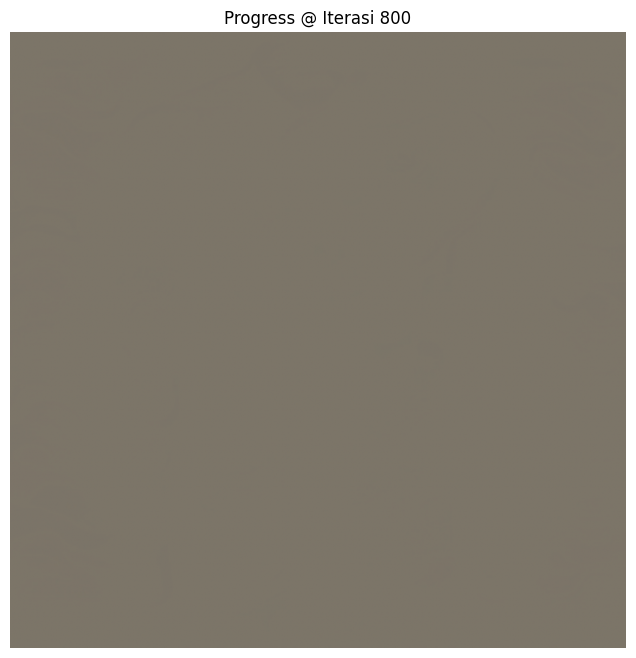

Iterasi 900/1000 | Waktu: 92.51s | Loss Total: 8479293.00
   Loss Konten: 2034081.00, Loss Gaya: 4082465.50, Loss TV: 2362746.25


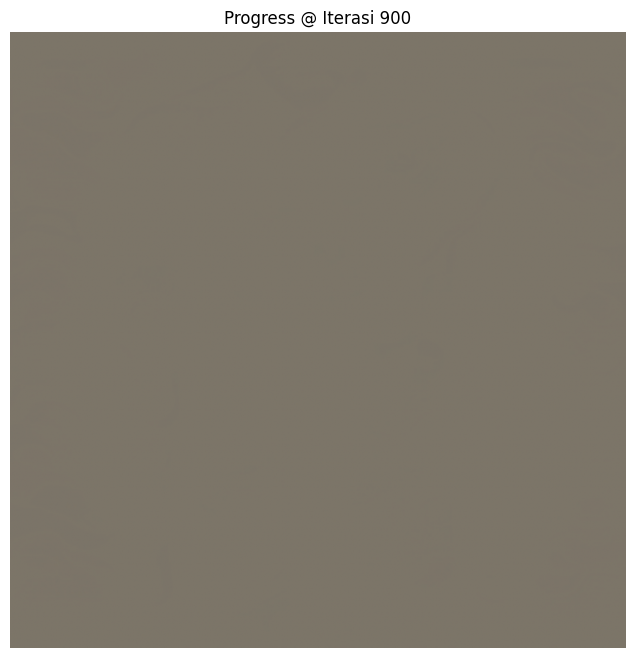

Iterasi 1000/1000 | Waktu: 101.85s | Loss Total: 9657920.00
   Loss Konten: 2045420.88, Loss Gaya: 5298526.50, Loss TV: 2313973.00


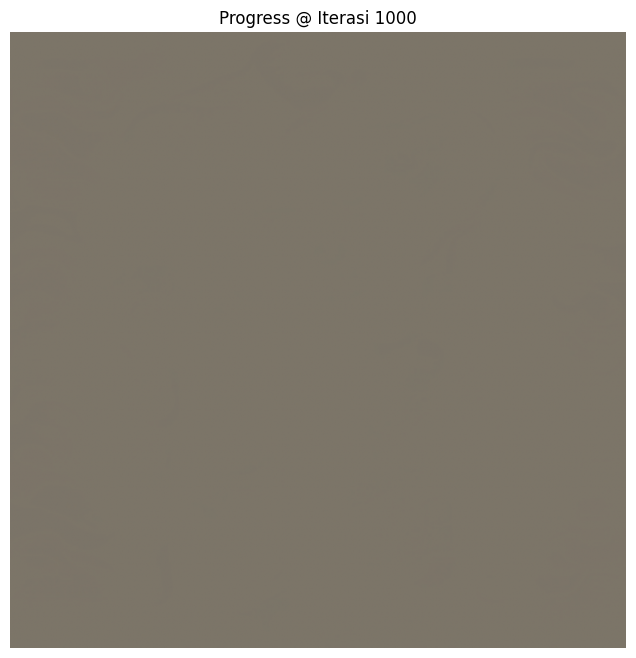


Proses selesai dalam 102.03 detik.


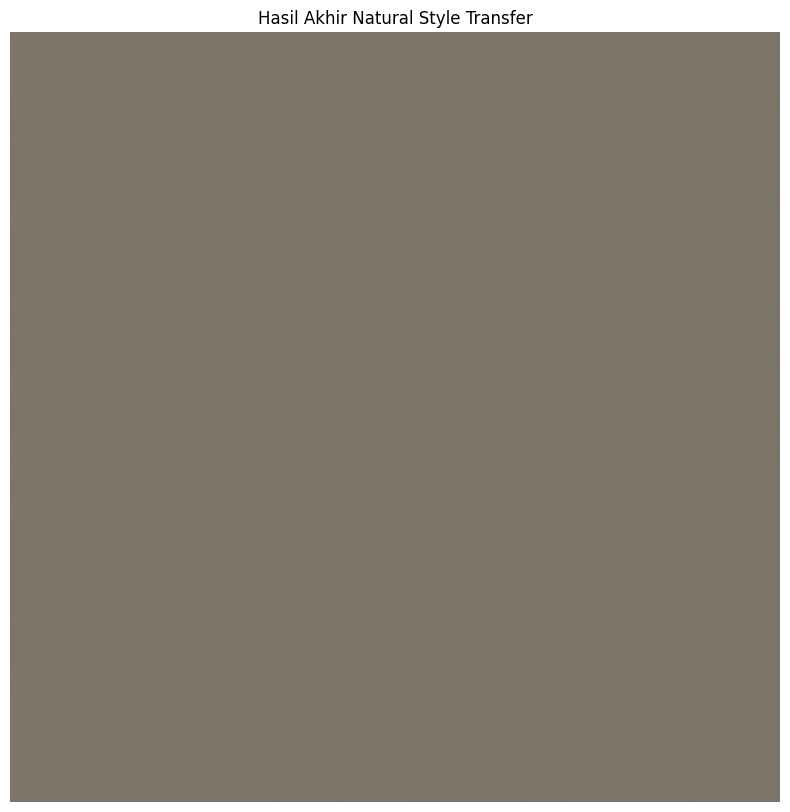


Hasil akhir disimpan di: /content/nst_output/hasil_style_transfer.jpg


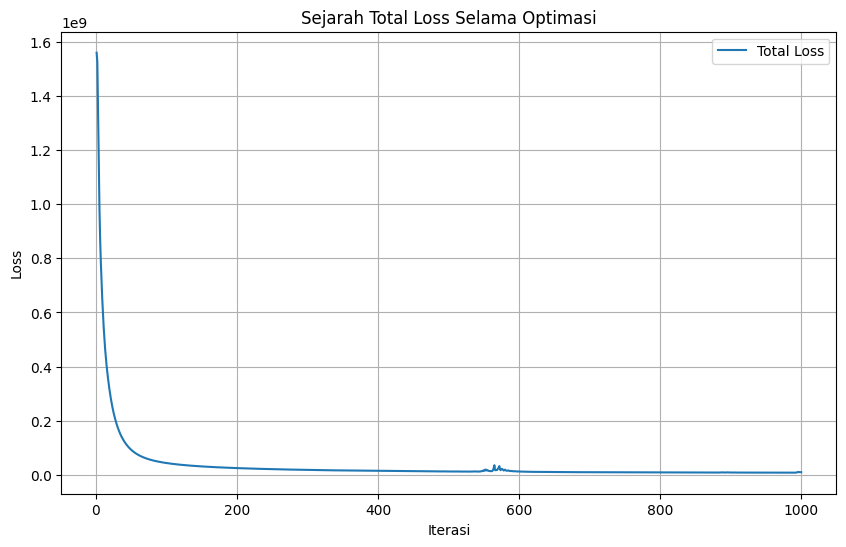


--- TIPS PAKAR ---
1. Cek Path: Pastikan path '/content/drive/MyDrive/Colab Notebooks/' sudah benar dan file gambar ada di sana.
2. Hyperparameter: Anda dapat bereksperimen dengan Content Weight (1e3) dan Style Weight (1e-2). Jika gaya kurang terlihat, naikkan Style Weight.
3. Ukuran Gambar: Untuk performa lebih cepat, turunkan img_size (misalnya 256). Untuk detail lebih baik, naikkan (misalnya 768) - tetapi butuh waktu lebih lama dan RAM/GPU lebih banyak.
4. Total Variation Loss: Sesuaikan total_variation_weight (saat ini 30) untuk mengontrol kehalusan gambar akhir; nilai yang lebih tinggi menghasilkan gambar yang lebih halus tetapi mungkin kurang detail.


In [1]:
# ==============================================================================
# Natural Style Transfer (Transfer Gaya Neural) menggunakan TensorFlow/Keras
# Penulis: Pakar Deep Learning dan Python Google Colab
# Model: VGG19 (untuk ekstraksi fitur konten dan gaya)
# ==============================================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
import functools
import os

# Memastikan TensorFlow 2.x digunakan
print(f"Versi TensorFlow: {tf.__version__}")

# --- KONFIGURASI FILE DAN LOKASI ---
# Ganti dengan path file yang sudah Anda tentukan
content_path = '/content/drive/MyDrive/Colab Notebooks/gambar kemeja.jpg'
style_path = '/content/drive/MyDrive/Colab Notebooks/gambar batik.jpg'
output_dir = '/content/nst_output' # Direktori untuk menyimpan hasil

# Buat direktori output jika belum ada
os.makedirs(output_dir, exist_ok=True)

# --- 1. MOUNT GOOGLE DRIVE ---
# Langkah ini harus dijalankan di Colab untuk mengakses file Anda
print("\n--- 1. Proses Mounting Google Drive ---")
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive berhasil di-mount. File siap diakses.")
except ImportError:
    print("Tidak berada di lingkungan Colab, melewati proses mounting Drive.")
except Exception as e:
    print(f"Gagal mounting Drive: {e}")

# --- 2. KONFIGURASI MODEL DAN HYPERPARAMETER ---
# Lapisan VGG19 untuk ekstraksi fitur konten dan gaya
content_layers = ['block5_conv2']
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

# Berat (weights) untuk Loss
content_weight = 1e3
style_weight = 1e-2
total_variation_weight = 30 # Menghaluskan gambar (menghindari pixel noise)

# Resolusi gambar yang akan diproses
img_size = 512 # Ukuran sisi terpanjang gambar

# Iterasi dan Learning Rate
num_iterations = 1000
learning_rate = 0.02
betas = (0.9, 0.999) # Parameter untuk Optimizer Adam

# --- 3. FUNGSI UTILITAS UNTUK GAMBAR ---

def load_img(path_to_img):
    """Memuat dan memproses gambar."""
    max_dim = img_size
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

def preprocess_img(img):
    """
    Menyiapkan gambar agar sesuai dengan input yang diharapkan oleh VGG19.
    Menggunakan mean dan standard deviation dari dataset ImageNet.
    """
    # Mengonversi dari [0, 1] ke [0, 255]
    img = img * 255
    # VGG19 menggunakan konvensi BGR dan mean yang spesifik
    vgg_mean = [103.939, 116.779, 123.68]
    # Urutan channel VGG adalah BGR, TensorFlow/PIL adalah RGB
    # tf.keras.applications.vgg19.preprocess_input menangani konversi ini
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(img)
    return preprocessed_input

def deprocess_img(processed_img):
    """Mengonversi output VGG kembali ke format yang dapat ditampilkan [0, 1]."""
    x = processed_img.copy()
    if len(x.shape) == 4:
        x = x[0, :, :, :]

    # Menghapus rata-rata VGG
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68

    # Konversi BGR ke RGB (karena VGG menggunakan BGR)
    x = x[:, :, ::-1]

    x = np.clip(x, 0, 255).astype('uint8')
    return x / 255.0 # Normalisasi kembali ke [0, 1] untuk tampilan

# --- 4. PEMBANGUNAN MODEL VGG19 BARU ---

def vgg_layers(layer_names):
    """Memuat VGG19 dan membuat model baru yang mengembalikan output dari layer-layer tertentu."""
    # Memuat VGG19 yang sudah dilatih di ImageNet
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    outputs = [vgg.get_layer(name).output for name in layer_names]

    model = tf.keras.Model([vgg.input], outputs)
    return model

# Model untuk menghitung content dan style features
style_extractor = vgg_layers(style_layers)
content_extractor = vgg_layers(content_layers)

# Model utama yang mengembalikan fitur style dan content
class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        """Input gambar diproses, lalu fitur dari layer-layer diekstrak."""
        inputs = preprocess_img(inputs)
        outputs = self.vgg(inputs)

        style_outputs = outputs[:self.num_style_layers]
        content_outputs = outputs[self.num_style_layers:]

        style_features = [self.gram_matrix(style_output)
                          for style_output in style_outputs]

        return {'style': style_features, 'content': content_outputs}

    def gram_matrix(self, input_tensor):
        """
        Menghitung matriks Gram (korelasi antar fitur) untuk Style Loss.
        """
        # Matriks Gram dihitung sebagai hasil kali matriks fitur dengan transposnya
        result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
        input_shape = tf.shape(input_tensor)
        num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
        # Normalisasi dengan ukuran total lokasi spasial
        return result / num_locations

# --- 5. FUNGI LOSS DAN OPTIMIZER ---

extractor = StyleContentModel(style_layers, content_layers)

# Memuat gambar dan fitur awal
content_image = load_img(content_path)
style_image = load_img(style_path)

# Mendapatkan fitur target (style dan content)
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

# Gambar awal yang akan dioptimalkan (image to be stylized)
image = tf.Variable(content_image)

# FIX 1: Mengganti 'beta1' dengan 'beta_1' dan menambahkan 'beta_2' untuk kompatibilitas TF 2.19+
optimizer = tf.optimizers.Adam(learning_rate=learning_rate, beta_1=betas[0], beta_2=betas[1], epsilon=1e-1)

@tf.function()
def train_step(image, style_targets, content_targets, extractor, content_weight, style_weight, total_variation_weight):
    """
    Satu langkah optimasi (training step).
    Menggunakan tf.function untuk kompilasi graph dan performa lebih cepat.
    """
    with tf.GradientTape() as tape:
        # 1. Ekstrak fitur dari gambar yang sedang dioptimalkan
        model_outputs = extractor(image)

        # 2. Hitung Content Loss
        content_score = 0
        for target_content, current_content in zip(content_targets, model_outputs['content']):
            content_score += tf.reduce_mean(tf.square(current_content - target_content))
        content_score *= content_weight

        # 3. Hitung Style Loss
        style_score = 0
        weight_per_style_layer = 1.0 / float(len(style_layers)) # Weight sama untuk semua layer gaya
        for target_style, current_style in zip(style_targets, model_outputs['style']):
            style_score += tf.reduce_mean(tf.square(current_style - target_style)) * weight_per_style_layer
        style_score *= style_weight

        # 4. Hitung Total Variation Loss (untuk smoothing)
        tv_loss = total_variation_weight * tf.image.total_variation(image)

        # 5. Total Loss
        loss = content_score + style_score + tv_loss

    # 6. Hitung dan Terapkan Gradien
    grad = tape.gradient(loss, image)
    optimizer.apply_gradients([(grad, image)])

    # Pastikan output tetap berada di batas [0, 1]
    image.assign(tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0))

    return loss, content_score, style_score, tv_loss


# --- 6. EKSEKUSI TRANSFER GAYA ---

# Tampilkan gambar awal dan gambar gaya
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(content_image[0].numpy())
plt.title("Gambar Konten (Kemeja)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(style_image[0].numpy())
plt.title("Gambar Gaya (Batik)")
plt.axis('off')

plt.show()

print("\n--- 7. Memulai Proses Transfer Gaya Neural ---")
print("Ini adalah langkah yang paling penting. Kami akan menggunakan model VGG19 untuk mengekstrak fitur dan Adam Optimizer untuk meminimalkan loss.")


start_time = time.time()
best_loss, best_img = float('inf'), None

# Logging Loss setiap 100 iterasi
plot_interval = 100
loss_history = []

for i in range(num_iterations):
    # Lakukan satu langkah training
    total_loss, c_loss, s_loss, tv_loss = train_step(image, style_targets, content_targets, extractor, content_weight, style_weight, total_variation_weight)

    # FIX 2 (Revisi): Menggunakan .item() untuk menjamin konversi ke skalar Python murni
    current_loss_value = total_loss.numpy().item()
    loss_history.append(current_loss_value)

    if current_loss_value < best_loss:
        # Update gambar terbaik
        best_loss = current_loss_value
        best_img = deprocess_img(image.numpy())

    if (i + 1) % plot_interval == 0:
        elapsed_time = time.time() - start_time
        print(f"Iterasi {i + 1}/{num_iterations} | Waktu: {elapsed_time:.2f}s | Loss Total: {current_loss_value:.2f}")
        # FIX 2 (Revisi): Menggunakan .item() untuk menjamin konversi ke skalar Python murni sebelum formatting
        print(f"   Loss Konten: {c_loss.numpy().item():.2f}, Loss Gaya: {s_loss.numpy().item():.2f}, Loss TV: {tv_loss.numpy().item():.2f}")

        # Tampilkan progress gambar
        plt.figure(figsize=(8, 8))
        plt.imshow(deprocess_img(image.numpy()))
        plt.title(f"Progress @ Iterasi {i+1}")
        plt.axis('off')
        plt.show()

end_time = time.time()
print(f"\nProses selesai dalam {(end_time - start_time):.2f} detik.")

# --- 8. TAMPILKAN DAN SIMPAN HASIL AKHIR ---

final_image_pil = Image.fromarray((best_img * 255).astype(np.uint8))
final_image_path = os.path.join(output_dir, "hasil_style_transfer.jpg")
final_image_pil.save(final_image_path)

plt.figure(figsize=(10, 10))
plt.imshow(final_image_pil)
plt.title("Hasil Akhir Natural Style Transfer")
plt.axis('off')
plt.show()

print(f"\nHasil akhir disimpan di: {final_image_path}")

# Tampilkan plot sejarah loss
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, num_iterations + 1), loss_history, label='Total Loss')
plt.title('Sejarah Total Loss Selama Optimasi')
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

print("\n--- TIPS PAKAR ---")
print("1. Cek Path: Pastikan path '/content/drive/MyDrive/Colab Notebooks/' sudah benar dan file gambar ada di sana.")
print("2. Hyperparameter: Anda dapat bereksperimen dengan Content Weight (1e3) dan Style Weight (1e-2). Jika gaya kurang terlihat, naikkan Style Weight.")
print("3. Ukuran Gambar: Untuk performa lebih cepat, turunkan img_size (misalnya 256). Untuk detail lebih baik, naikkan (misalnya 768) - tetapi butuh waktu lebih lama dan RAM/GPU lebih banyak.")
print("4. Total Variation Loss: Sesuaikan total_variation_weight (saat ini 30) untuk mengontrol kehalusan gambar akhir; nilai yang lebih tinggi menghasilkan gambar yang lebih halus tetapi mungkin kurang detail.")